# 1. Setup & Environment
Bagian ini digunakan untuk mengimpor semua pustaka yang dibutuhkan dan melakukan konfigurasi *hardware* (GPU) agar pelatihan model berjalan optimal.


In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input

# Enable GPU Memory Growth to prevent TensorFlow from allocating all GPU memory at once
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU Memory Growth Enabled")
    except RuntimeError as e:
        print(e)

print("TensorFlow Version:", tf.__version__)
print("GPU Ditemukan:" if gpus else "GPU Tidak Ada")

2026-03-12 08:24:25.737522: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-12 08:24:25.850884: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-12 08:24:27.871442: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPU Memory Growth Enabled
TensorFlow Version: 2.20.0
GPU Ditemukan:


# 2. Hyperparameter Configuration
Menyimpan semua parameter statis di satu tempat agar mempermudah eksperimen atau penyesuaian jika diperlukan di masa mendatang.

In [2]:
# Configurations
TRAIN_DIR = 'Apple_Disease_Dataset/train'
IMG_SIZE = (224, 224)
BATCH_SIZE = 8
SEED = 123
EPOCHS_PHASE1 = 15
EPOCHS_PHASE2 = 20

MODEL_SAVE_NAME = "resnet50v2_apple_disease.keras"
TFLITE_SAVE_NAME = "resnet50v2_apple_disease.tflite"

# 3. Data Preparation & Exploratory Data Analysis (EDA)
Membaca struktur direktori data dan memvisualisasikan sampel gambar serta distribusi kelas untuk memastikan dataset tidak mengalami *imbalance*.

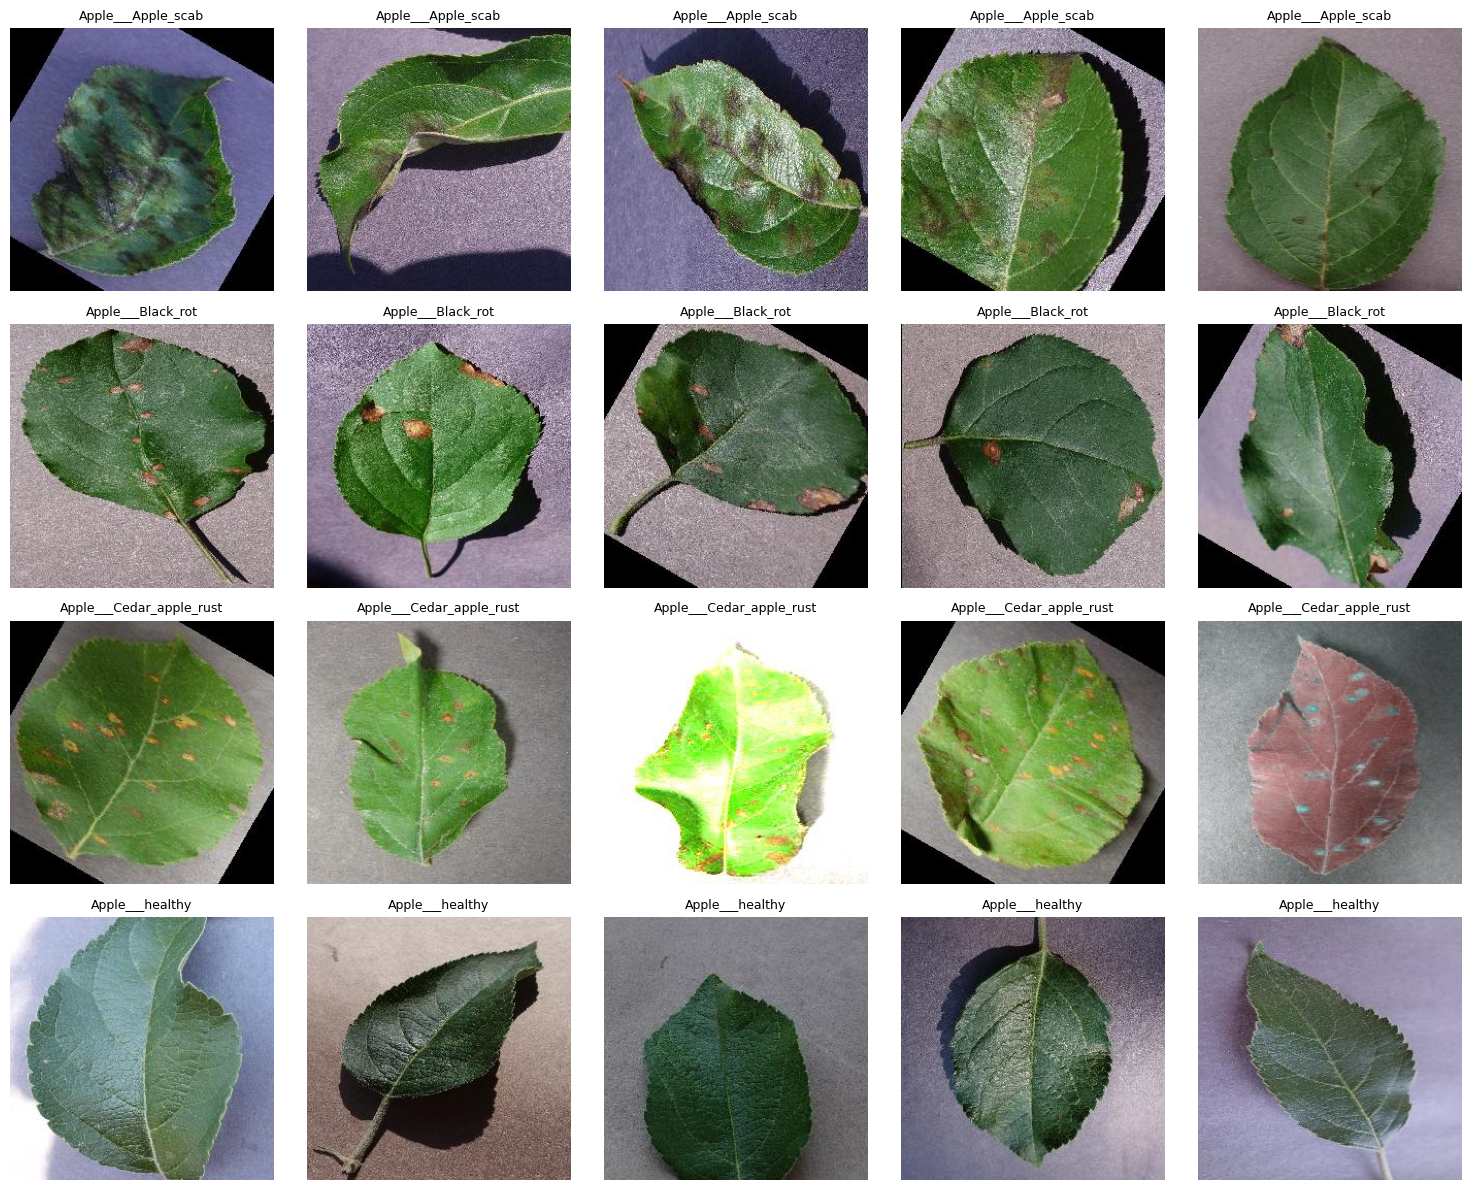

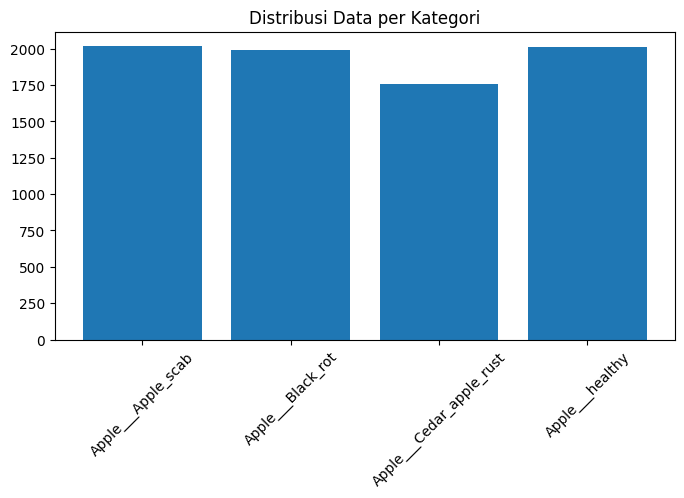

In [3]:
class_names = sorted(os.listdir(TRAIN_DIR))
apple_images = {class_name: os.listdir(os.path.join(TRAIN_DIR, class_name)) for class_name in class_names}

# 3.1 Visualisasi Sampel Data
fig, axs = plt.subplots(len(class_names), 5, figsize=(15, 12))

for i, class_name in enumerate(class_names):
    random_images = random.sample(apple_images[class_name], 5)
    for j, image_name in enumerate(random_images):
        img_path = os.path.join(TRAIN_DIR, class_name, image_name)
        img = Image.open(img_path)
        axs[i, j].imshow(img)
        axs[i, j].set_title(class_name, fontsize=9)
        axs[i, j].axis('off')

plt.tight_layout()
plt.show()

# 3.2 Visualisasi Distribusi Kelas
counts = [len(apple_images[c]) for c in class_names]

plt.figure(figsize=(8,4))
plt.bar(class_names, counts)
plt.title("Distribusi Data per Kategori")
plt.xticks(rotation=45)
plt.show()

# 4. Data Pipeline
Membangun *pipeline* data menggunakan `tf.data` untuk memuat gambar secara dinamis (tidak memakan RAM) dan membaginya menjadi set pelatihan dan validasi.

In [4]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Optimize data loading performance
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)

Found 7771 files belonging to 4 classes.
Using 6217 files for training.


I0000 00:00:1773278897.498511    7662 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1763 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 7771 files belonging to 4 classes.
Using 1554 files for validation.


# 5. Model Architecture (ResNet50V2)
Membangun model menggunakan arsitektur ResNet50V2 (*Transfer Learning*), mengintegrasikan *data augmentation*, lapisan pra-pemrosesan (*preprocessing*), dan lapisan klasifikasi (*Dense*).

In [5]:
# Data augmentation to handle spatial variance and reduce overfitting
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(height_factor=0.2, width_factor=0.2),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    layers.RandomBrightness(factor=0.2),
    layers.RandomContrast(factor=0.2),
], name="Augmentation_Layer")

# Load pre-trained ResNet50V2 model without top classification layers
base_model = ResNet50V2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model weights for initial feature extraction
base_model.trainable = False  

# Assemble the final model pipeline
model = tf.keras.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    data_augmentation,
    # Standardize input tensors to conform to ResNet50V2 required scaling
    layers.Lambda(preprocess_input, name="ResNet_Preprocess"),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3), # Regularization layer
    layers.Dense(len(class_names), activation='softmax', name="Output_Prediksi")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Augmentation_Layer (Sequential) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ResNet_Preprocess (Lambda)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Prediksi (Dense)         │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,572,996 (89.92 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 23,564,800 (89.89 MB)

# 6. Training Phase 1: Feature Extraction
Melatih hanya lapisan *Dense* terakhir (*classifier*) sementara bobot `base_model` dibekukan (*frozen*). Hal ini bertujuan untuk mengadaptasi *classifier* acak dengan fitur-fitur yang diekstraksi oleh ResNet50V2 tanpa merusak representasi pola yang sudah ada.

In [7]:
# Prevent overfitting by stopping training if validation loss does not improve
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS_PHASE1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
778/778 ━━━━━━━━━━━━━━━━━━━━ 53s 67ms/step - accuracy: 0.9675 - loss: 0.0931 - val_accuracy: 0.9607 - val_loss: 0.0926
Epoch 2/15
778/778 ━━━━━━━━━━━━━━━━━━━━ 47s 61ms/step - accuracy: 0.9611 - loss: 0.1096 - val_accuracy: 0.9730 - val_loss: 0.0668
Epoch 3/15
778/778 ━━━━━━━━━━━━━━━━━━━━ 92s 66ms/step - accuracy: 0.9706 - loss: 0.0875 - val_accuracy: 0.9768 - val_loss: 0.0657
Epoch 4/15
778/778 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - accuracy: 0.9669 - loss: 0.0958 - val_accuracy: 0.9820 - val_loss: 0.0519
Epoch 5/15
778/778 ━━━━━━━━━━━━━━━━━━━━ 53s 68ms/step - accuracy: 0.9680 - loss: 0.0906 - val_accuracy: 0.9588 - val_loss: 0.1104
Epoch 6/15
778/778 ━━━━━━━━━━━━━━━━━━━━ 51s 65ms/step - accuracy: 0.9699 - loss: 0.0881 - val_accuracy: 0.9846 - val_loss: 0.0469
Epoch 7/15
778/778 ━━━━━━━━━━━━━━━━━━━━ 57s 73ms/step - accuracy: 0.9686 - loss: 0.0872 - val_accuracy: 0.9807 - val_loss: 0.0605
Epoch 8/15
778/778 ━━━━━━━━━━━━━━━━━━━━ 54s 69ms/step - accuracy: 0.9683 - loss: 0.0957 - 

# 7. Training Phase 2: Fine-Tuning
Membuka kunci (*unfreeze*) beberapa lapisan terakhir pada `base_model` dan melatih ulang seluruh model dengan *learning rate* yang sangat kecil. Bertujuan untuk menyempurnakan ekstraksi fitur secara spesifik pada dataset daun apel.

In [10]:
# 7. Training Phase 2: Fine-Tuning
# Unfreeze the base model
base_model.trainable = True

# Freeze all layers except the last 30 for fine-tuning specific features
for layer in base_model.layers[:-30]:
    layer.trainable = False

# BIKIN WASIT BARU KHUSUS PHASE 2 (Biar ingatannya di-reset)
early_stop_finetune = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,  # <-- Kesabarannya kita naikin jadi 5 karena ini Fine-Tuning
    restore_best_weights=True
)

# Recompile with a significantly lower learning rate to prevent catastrophic forgetting
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS_PHASE2,
    callbacks=[early_stop_finetune],  # <-- PAKAI WASIT BARU DI SINI
    verbose=1
)

Epoch 1/20
778/778 ━━━━━━━━━━━━━━━━━━━━ 87s 101ms/step - accuracy: 0.9440 - loss: 0.1622 - val_accuracy: 0.9755 - val_loss: 0.0578
Epoch 2/20
778/778 ━━━━━━━━━━━━━━━━━━━━ 85s 109ms/step - accuracy: 0.9566 - loss: 0.1234 - val_accuracy: 0.9891 - val_loss: 0.0366
Epoch 3/20
778/778 ━━━━━━━━━━━━━━━━━━━━ 79s 101ms/step - accuracy: 0.9661 - loss: 0.0912 - val_accuracy: 0.9833 - val_loss: 0.0483
Epoch 4/20
778/778 ━━━━━━━━━━━━━━━━━━━━ 79s 101ms/step - accuracy: 0.9714 - loss: 0.0784 - val_accuracy: 0.9923 - val_loss: 0.0226
Epoch 5/20
778/778 ━━━━━━━━━━━━━━━━━━━━ 80s 103ms/step - accuracy: 0.9767 - loss: 0.0607 - val_accuracy: 0.9878 - val_loss: 0.0344
Epoch 6/20
778/778 ━━━━━━━━━━━━━━━━━━━━ 84s 107ms/step - accuracy: 0.9776 - loss: 0.0575 - val_accuracy: 0.9923 - val_loss: 0.0204
Epoch 7/20
778/778 ━━━━━━━━━━━━━━━━━━━━ 80s 102ms/step - accuracy: 0.9810 - loss: 0.0556 - val_accuracy: 0.9884 - val_loss: 0.0280
Epoch 8/20
778/778 ━━━━━━━━━━━━━━━━━━━━ 79s 102ms/step - accuracy: 0.9836 - loss: 0

# 8. Evaluation & Visualization
Mengevaluasi kinerja keseluruhan model menggunakan kurva pembelajaran (*Learning Curves*), metrik presisi/recall (*Classification Report*), dan *Confusion Matrix*.

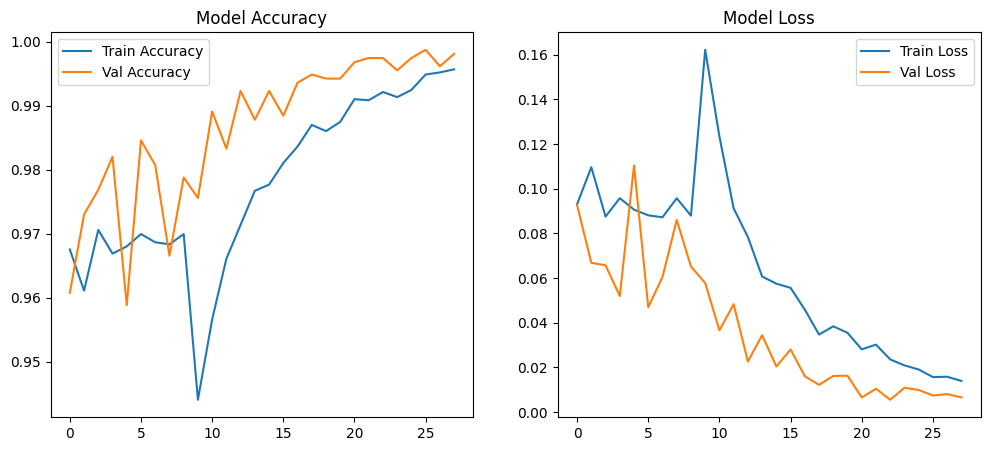

2026-03-12 09:49:35.368540: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


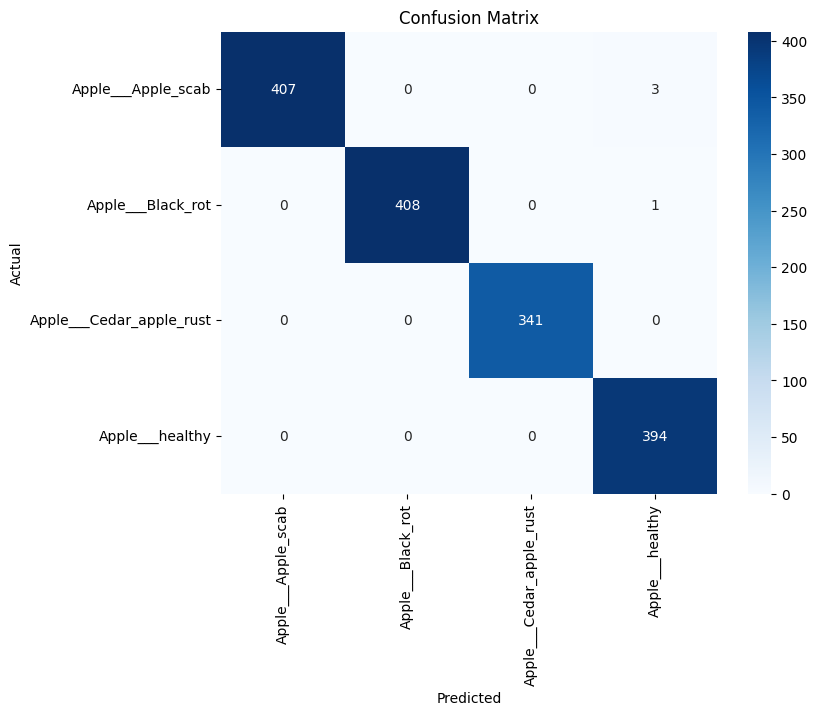


Classification Report:

                          precision    recall  f1-score   support

      Apple___Apple_scab       1.00      0.99      1.00       410
       Apple___Black_rot       1.00      1.00      1.00       409
Apple___Cedar_apple_rust       1.00      1.00      1.00       341
         Apple___healthy       0.99      1.00      0.99       394

                accuracy                           1.00      1554
               macro avg       1.00      1.00      1.00      1554
            weighted avg       1.00      1.00      1.00      1554



In [11]:
# 8.1 Learning Curves Plot
acc = history.history['accuracy'] + fine_tune_history.history['accuracy']
val_acc = history.history['val_accuracy'] + fine_tune_history.history['val_accuracy']

loss = history.history['loss'] + fine_tune_history.history['loss']
val_loss = history.history['val_loss'] + fine_tune_history.history['val_loss']

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.legend()
plt.title("Model Accuracy")

plt.subplot(1,2,2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.legend()
plt.title("Model Loss")

plt.show()

# 8.2 Confusion Matrix & Classification Report
y_true = []
y_pred = []

for images, labels in val_dataset:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# 9. Model Export & TFLite Conversion
Menyimpan model ke dalam format `.keras` untuk inferensi Python/Web dan mengonversinya ke dalam format `.tflite` untuk *deployment* di perangkat berdaya rendah (Edge/Mobile).

In [ ]:
# 9.1 Save Standard Keras Model
model.save(MODEL_SAVE_NAME)
print(f"Model successfully saved as: {MODEL_SAVE_NAME}")

# 9.2 Convert to TFLite
print("Initiating TFLite conversion...")

# Load model allowing for custom functions and safe mode bypass for nested layers
model_keras = tf.keras.models.load_model(
    MODEL_SAVE_NAME,
    custom_objects={"preprocess_input": preprocess_input},
    safe_mode=False
)

converter = tf.lite.TFLiteConverter.from_keras_model(model_keras)

# Enable custom operations required by the Lambda preprocessing layer
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS, 
    tf.lite.OpsSet.SELECT_TF_OPS
]

tflite_model = converter.convert()

with open(TFLITE_SAVE_NAME, "wb") as f:
    f.write(tflite_model)

print(f"Model successfully converted to TFLite format: {TFLITE_SAVE_NAME}")

Model successfully saved as: resnet50v2_apple_disease.keras
Initiating TFLite conversion...
INFO:tensorflow:Assets written to: /tmp/tmpwii43mi0/assets


INFO:tensorflow:Assets written to: /tmp/tmpwii43mi0/assets


Saved artifact at '/tmp/tmpwii43mi0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  126770522897072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126770522896016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126769966944624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126769966943216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126769966943568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126769966943040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126769966949200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126769966948848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126769966951840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126769966950432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1267699669506

W0000 00:00:1773285883.836894    7662 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1773285883.837200    7662 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-03-12 10:24:43.841463: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpwii43mi0
2026-03-12 10:24:43.859911: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-03-12 10:24:43.859940: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpwii43mi0
I0000 00:00:1773285883.987334    7662 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2026-03-12 10:24:44.012208: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-03-12 10:24:44.866103: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpwii43mi0
2026-03-12 10:24:45.037177: I tensorflow/cc/saved_model/loader.cc:471] SavedModel 

Model successfully converted to TFLite format: resnet50v2_apple_disease.tflite
